# Question 1

In [2]:
import numpy as np

class Perceptron:
    def __init__(self, input_size, learning_rate=0.1, epochs=100):
        self.weights = np.zeros(input_size + 1)
        self.learning_rate = learning_rate
        self.epochs = epochs

    def activation_function(self, x):
        return 1 if x >= 0 else 0

    def predict(self, inputs):
        summation = np.dot(inputs, self.weights[1:]) + self.weights[0]
        return self.activation_function(summation)

    def train(self, training_inputs, labels):
        for _ in range(self.epochs):
            for inputs, label in zip(training_inputs, labels):
                prediction = self.predict(inputs)
                self.weights[1:] += self.learning_rate * (label - prediction) * inputs
                self.weights[0] += self.learning_rate * (label - prediction)


# Implementing OR gate
training_inputs_or = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
labels_or = np.array([0, 1, 1, 1])

perceptron_or = Perceptron(2)
perceptron_or.train(training_inputs_or, labels_or)

# Test OR gate
print("OR Gate:")
for inputs in training_inputs_or:
    print(f"{inputs[0]} OR {inputs[1]} = {perceptron_or.predict(inputs)}")


# Implementing AND gate
training_inputs_and = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
labels_and = np.array([0, 0, 0, 1])

perceptron_and = Perceptron(2)
perceptron_and.train(training_inputs_and, labels_and)

# Test AND gate
print("\nAND Gate:")
for inputs in training_inputs_and:
    print(f"{inputs[0]} AND {inputs[1]} = {perceptron_and.predict(inputs)}")


OR Gate:
0 OR 0 = 0
0 OR 1 = 1
1 OR 0 = 1
1 OR 1 = 1

AND Gate:
0 AND 0 = 0
0 AND 1 = 0
1 AND 0 = 0
1 AND 1 = 1


# Question 2

C:\Users\hassa\AppData\Local\Temp\ipykernel_11280\3576910625.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['race_id'] = df_cleaned['race_id'].astype('category')
C:\Users\hassa\AppData\Local\Temp\ipykernel_11280\3576910625.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['horse_id'] = df_cleaned['horse_id'].astype('category')
C:\Users\hassa\AppData\Local\Temp\ipykernel_11280\3576910625.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Dat

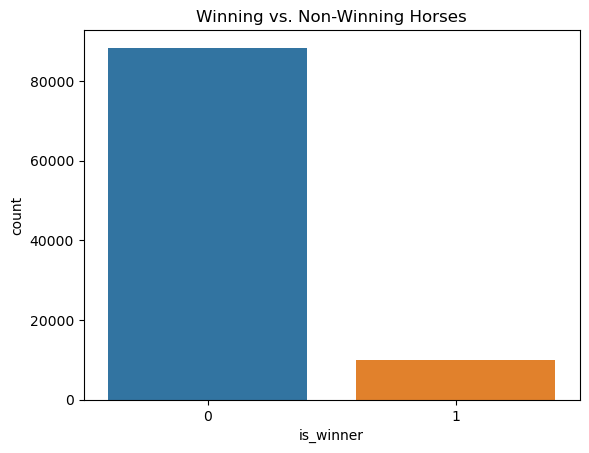

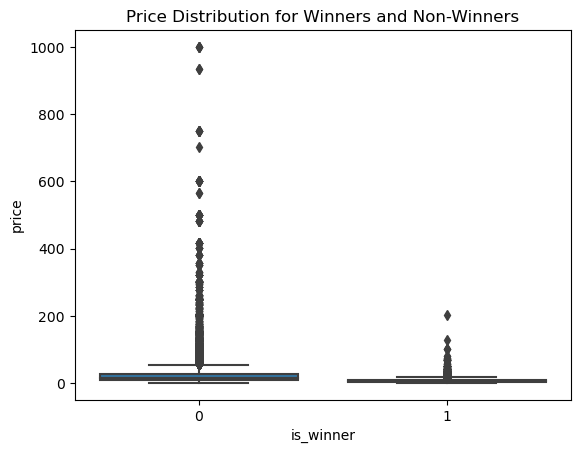

C:\Users\hassa\AppData\Local\Temp\ipykernel_11280\3576910625.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['race_id_reduced'] = df_cleaned['race_id'].apply(lambda x: x if x in top_race_ids else 'Other')
C:\Users\hassa\AppData\Local\Temp\ipykernel_11280\3576910625.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['horse_id_reduced'] = df_cleaned['horse_id'].apply(lambda x: x if x in top_horse_ids else 'Other')


Accuracy: 99.93%

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     17734
           1       1.00      1.00      1.00      1944

    accuracy                           1.00     19678
   macro avg       1.00      1.00      1.00     19678
weighted avg       1.00      1.00      1.00     19678



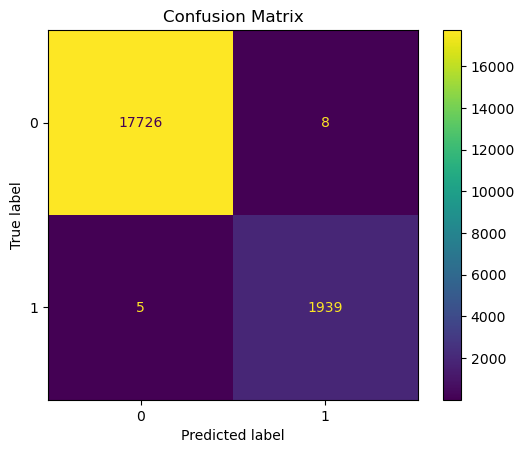

R^2 (Coefficient of Determination): 0.99
Mean Squared Error (MSE): 0.00


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, r2_score, mean_squared_error
from sklearn.metrics import ConfusionMatrixDisplay

# Load dataset
df = pd.read_csv('horse_racing_dataset.csv')

# Data cleaning
df_cleaned = df.dropna(subset=['calc_position'])
df_cleaned['race_id'] = df_cleaned['race_id'].astype('category')
df_cleaned['horse_id'] = df_cleaned['horse_id'].astype('category')
df_cleaned['is_winner'] = (df_cleaned['calc_position'] == 1).astype(int)

# Data visualization
sns.countplot(x='is_winner', data=df_cleaned)
plt.title('Winning vs. Non-Winning Horses')
plt.show()

sns.boxplot(x='is_winner', y='price', data=df_cleaned)
plt.title('Price Distribution for Winners and Non-Winners')
plt.show()

# Feature engineering
top_race_ids = df_cleaned['race_id'].value_counts().nlargest(10).index
df_cleaned['race_id_reduced'] = df_cleaned['race_id'].apply(lambda x: x if x in top_race_ids else 'Other')

top_horse_ids = df_cleaned['horse_id'].value_counts().nlargest(10).index
df_cleaned['horse_id_reduced'] = df_cleaned['horse_id'].apply(lambda x: x if x in top_horse_ids else 'Other')

df_encoded = pd.get_dummies(df_cleaned, columns=['race_id_reduced', 'horse_id_reduced'])

# Model training and evaluation
X = df_encoded.drop('is_winner', axis=1)
y = df_encoded['is_winner']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

imputer = SimpleImputer(strategy='mean')
scaler = StandardScaler()

X_train_imputed = imputer.fit_transform(X_train)
X_train_scaled = scaler.fit_transform(X_train_imputed)

X_test_imputed = imputer.transform(X_test)
X_test_scaled = scaler.transform(X_test_imputed)

mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, activation='relu', solver='adam', random_state=42)
mlp.fit(X_train_scaled, y_train)
y_pred = mlp.predict(X_test_scaled)

# Model evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Confusion Matrix')
plt.show()

r2 = r2_score(y_test, y_pred)
print(f"R^2 (Coefficient of Determination): {r2:.2f}")
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.2f}")
